In [1]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/Final_Year_Project/big_startup_secsees_dataset.csv'

Mounted at /content/drive


In [3]:
# Install any missing libraries
!pip install -q pandas numpy matplotlib seaborn scikit-learn imbalanced-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent plot styling throughout the project
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

# Colour palette — one colour per status class, used in every plot
PALETTE = {
    'operating': '#2196F3',
    'closed':    '#F44336',
    'acquired':  '#4CAF50',
    'ipo':       '#FF9800'
}

print('Libraries loaded successfully.')

Libraries loaded successfully.


## **Data Loading & Initial Inspection**

In [5]:
df_raw = pd.read_csv(DATA_PATH)
print(f'Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

Dataset loaded: 66,368 rows × 14 columns


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at
0,/organization/-fame,#fame,http://livfame.com,Media,10000000,operating,IND,16,Mumbai,Mumbai,1,NaN,05/01/2015,05/01/2015
1,/organization/-qounter,:Qounter,http://www.qounter.com,Application Platforms|Real Time|Social Network...,700000,operating,USA,DE,DE - Other,Delaware City,2,04/09/2014,01/03/2014,14/10/2014
2,/organization/-the-one-of-them-inc-,"(THE) ONE of THEM,Inc.",http://oneofthem.jp,Apps|Games|Mobile,3406878,operating,NaN,NaN,NaN,NaN,1,NaN,30/01/2014,30/01/2014
3,/organization/0-6-com,0-6.com,http://www.0-6.com,Curated Web,2000000,operating,CHN,22,Beijing,Beijing,1,01/01/2007,19/03/2008,19/03/2008
4,/organization/004-technologies,004 Technologies,http://004gmbh.de/en/004-interact,Software,-,operating,USA,IL,"Springfield, Illinois",Champaign,1,01/01/2010,24/07/2014,24/07/2014


In [6]:
# Check data types
print('Column data types:')
print(df_raw.dtypes)
print()
print('Unique values in key columns:')
for col in ['status', 'country_code', 'funding_rounds']:
    print(f'  {col}: {df_raw[col].nunique()} unique values')

Column data types:
permalink            object
name                 object
homepage_url         object
category_list        object
funding_total_usd    object
status               object
country_code         object
state_code           object
region               object
city                 object
funding_rounds        int64
founded_at           object
first_funding_at     object
last_funding_at      object
dtype: object

Unique values in key columns:
  status: 4 unique values
  country_code: 137 unique values
  funding_rounds: 19 unique values


In [7]:
# Missing value audit
# NOTE: funding_total_usd uses "-" as a placeholder (not NaN), so we check both
missing_counts = df_raw.isnull().sum()
dash_counts    = (df_raw == '-').sum()

missing_df = pd.DataFrame({
    'NaN count':     missing_counts,
    'Dash count':    dash_counts,
    'Total missing': missing_counts + dash_counts,
    'Missing %':     ((missing_counts + dash_counts) / len(df_raw) * 100).round(2)
})
missing_df = missing_df[missing_df['Total missing'] > 0].sort_values('Missing %', ascending=False)
print('Missing value summary:')
missing_df

Missing value summary:


,NaN count,Dash count,Total missing,Missing %
founded_at,15221,0,15221,22.93
funding_total_usd,0,12785,12785,19.26
state_code,8547,0,8547,12.88
region,8030,0,8030,12.10
city,8028,0,8028,12.10
country_code,6958,0,6958,10.48
homepage_url,5058,0,5058,7.62
category_list,3148,0,3148,4.74
first_funding_at,24,0,24,0.04
name,1,0,1,0.00


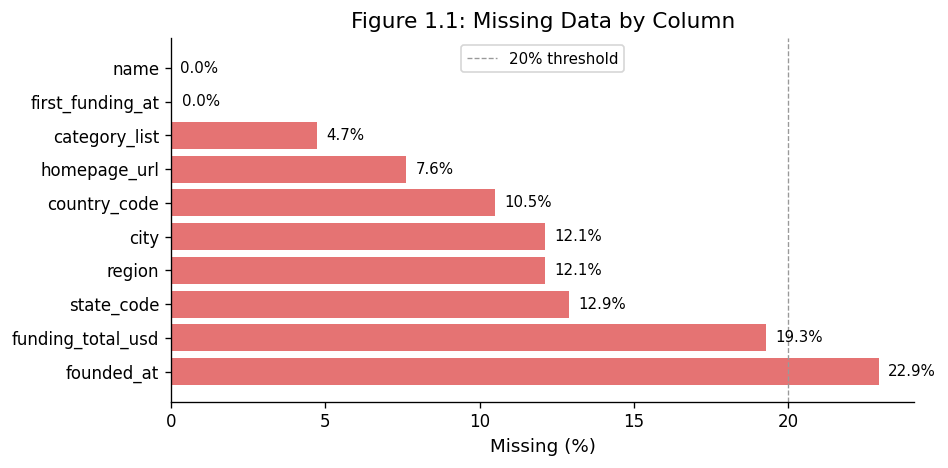

In [8]:
# Plot missing values
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df['Missing %'], color='#E57373', edgecolor='none')
ax.axvline(20, color='#999', linestyle='--', linewidth=0.8, label='20% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Figure 1.1: Missing Data by Column')
ax.legend(fontsize=9)
for bar, val in zip(bars, missing_df['Missing %']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig1_missing_data.png', bbox_inches='tight')
plt.show()

## **Data Cleaning & Type Correction**

In [9]:
df = df_raw.copy()

# 3.1 — Drop non-predictive identifier columns
df.drop(columns=['permalink', 'homepage_url'], inplace=True)

# 3.2 — Convert funding_total_usd: replace '-' with NaN, then cast to float
df['funding_total_usd'] = pd.to_numeric(df['funding_total_usd'], errors='coerce')
print(f'funding_total_usd — valid: {df["funding_total_usd"].notna().sum():,}  '
      f'missing: {df["funding_total_usd"].isna().sum():,}')

# 3.3 — Parse date columns
# Format is DD/MM/YYYY — dayfirst=True is critical, otherwise April and September get swapped
date_cols = ['founded_at', 'first_funding_at', 'last_funding_at']
for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

print('\nDate parsing results:')
for col in date_cols:
    print(f'  {col}: {df[col].notna().sum():,} valid | '
          f'range: {df[col].min().date()} → {df[col].max().date()}')

# 3.4 — Standardise string columns (strip whitespace, lowercase status)
df['status'] = df['status'].str.strip().str.lower()
for col in ['country_code', 'region', 'city']:
    df[col] = df[col].str.strip()

# 3.5 — Confirm target variable is clean (no nulls allowed)
print('\nTarget variable distribution:')
print(df['status'].value_counts())
assert df['status'].isnull().sum() == 0, 'ERROR: Nulls found in status column!'
print('\nTarget variable is clean — no null values.')

funding_total_usd — valid: 53,583  missing: 12,785

Date parsing results:
  founded_at: 51,038 valid | range: 1901-01-01 → 2105-02-17
  first_funding_at: 66,341 valid | range: 1960-01-01 → 2015-12-05
  last_funding_at: 66,368 valid | range: 1971-01-01 → 2115-12-01

Target variable distribution:
status
operating    53034
closed        6238
acquired      5549
ipo           1547
Name: count, dtype: int64

Target variable is clean — no null values.


## **Feature Engineering**

In [10]:
# Reference date = approximate dataset snapshot date
# This is used to compute "days since last funding"
REFERENCE_DATE = pd.Timestamp('2016-01-01')

# 4.1 — Temporal features
df['startup_age_days'] = (df['last_funding_at'] - df['founded_at']).dt.days
df['funding_duration_days'] = (df['last_funding_at'] - df['first_funding_at']).dt.days
df['founded_year'] = df['founded_at'].dt.year
df['days_since_last_funding'] = (REFERENCE_DATE - df['last_funding_at']).dt.days.clip(lower=0)

# 4.2 — Funding features
# log1p handles zeros gracefully: log1p(0) = 0, avoids log(0) = -inf
df['log_funding'] = np.log1p(df['funding_total_usd'])

# Funding velocity = average raise per round
df['funding_velocity'] = np.where(
    df['funding_rounds'] > 0,
    df['funding_total_usd'] / df['funding_rounds'],
    np.nan
)

# 4.3 — Geographic flags
AFRICA_CODES = {
    'KEN', 'NGA', 'ZAF', 'EGY', 'GHA', 'TZA', 'ETH', 'RWA',
    'UGA', 'SEN', 'MAR', 'TUN', 'CIV', 'AGO', 'MOZ', 'ZWE',
    'ZMB', 'BWA', 'NAM', 'MWI'
}
df['is_africa'] = df['country_code'].isin(AFRICA_CODES).astype(int)
df['is_kenya']  = (df['country_code'] == 'KEN').astype(int)

# 4.4 — Primary category (first item in the pipe-delimited category_list)
df['primary_category'] = (
    df['category_list']
    .fillna('Unknown')
    .str.split('|')
    .str[0]
    .str.strip()
)

# 4.5 — Number of sectors a startup operates in (diversification signal)
df['num_categories'] = (
    df['category_list']
    .fillna('')
    .str.split('|')
    .apply(lambda x: len([c for c in x if c.strip()]))
)

print('New features created:')
new_cols = [
    'startup_age_days', 'funding_duration_days', 'founded_year',
    'days_since_last_funding', 'log_funding', 'funding_velocity',
    'is_africa', 'is_kenya', 'primary_category', 'num_categories'
]
df[new_cols].describe(include='all').T[['count', 'mean', 'min', 'max']]

New features created:


,count,mean,min,max
startup_age_days,51038.00,1651.33,-33055.00,41329.00
funding_duration_days,66341.00,342.22,0.00,36994.00
founded_year,51038.00,2008.06,1901.00,2105.00
days_since_last_funding,66368.00,1284.14,0.00,16436.00
log_funding,53583.00,14.37,0.69,24.13
funding_velocity,53583.00,9366929.42,1.00,17600000000.00
is_africa,66368.00,0.00,0.00,1.00
is_kenya,66368.00,0.00,0.00,1.00
primary_category,66368,NaN,NaN,NaN
num_categories,66368.00,2.30,0.00,44.00


## **Missing Value Imputation**

In [11]:
numeric_cols = [
    'funding_total_usd', 'log_funding', 'funding_velocity',
    'startup_age_days', 'funding_duration_days', 'founded_year'
]
print('Missing values BEFORE imputation:')
print(df[numeric_cols].isnull().sum())

Missing values BEFORE imputation:
funding_total_usd        12785
log_funding              12785
funding_velocity         12785
startup_age_days         15330
funding_duration_days       27
founded_year             15330
dtype: int64


In [12]:
# 5.1 — funding_total_usd: median per sector (better than global median
#        because funding norms vary widely — Biotech >> Media, for example)
cat_median  = df.groupby('primary_category')['funding_total_usd'].transform('median')
global_median = df['funding_total_usd'].median()
df['funding_total_usd'] = df['funding_total_usd'].fillna(cat_median)
df['funding_total_usd'] = df['funding_total_usd'].fillna(global_median)  # fallback

# Recompute log_funding after imputation
df['log_funding'] = np.log1p(df['funding_total_usd'])

# 5.2 — funding_velocity: recompute now that funding is complete
df['funding_velocity'] = df['funding_total_usd'] / df['funding_rounds'].clip(lower=1)

# 5.3 — founded_year: global median (weak signal, sector-specific less important)
median_year = int(df['founded_year'].median())
df['founded_year'] = df['founded_year'].fillna(median_year).astype(int)

# 5.4 — startup_age_days: median per founding year
age_by_year = df.groupby('founded_year')['startup_age_days'].transform('median')
df['startup_age_days'] = df['startup_age_days'].fillna(age_by_year)
df['startup_age_days'] = df['startup_age_days'].fillna(df['startup_age_days'].median())

# 5.5 — funding_duration_days: 0 for single-round startups (no duration)
df['funding_duration_days'] = df['funding_duration_days'].fillna(0).clip(lower=0)

# 5.6 — country_code / region / city: preserve as 'UNK' / 'Unknown'
#        (dropping rows would cost us 10%+ of the dataset)
df['country_code'] = df['country_code'].fillna('UNK')
df['region'] = df['region'].fillna('Unknown')
df['city']   = df['city'].fillna('Unknown')

print('Missing values AFTER imputation:')
print(df[numeric_cols].isnull().sum())
print('\nAll critical columns clean:', df[numeric_cols].isnull().sum().sum() == 0)

Missing values AFTER imputation:
funding_total_usd        0
log_funding              0
funding_velocity         0
startup_age_days         0
funding_duration_days    0
founded_year             0
dtype: int64

All critical columns clean: True


## **Exploratory Data Analysis**

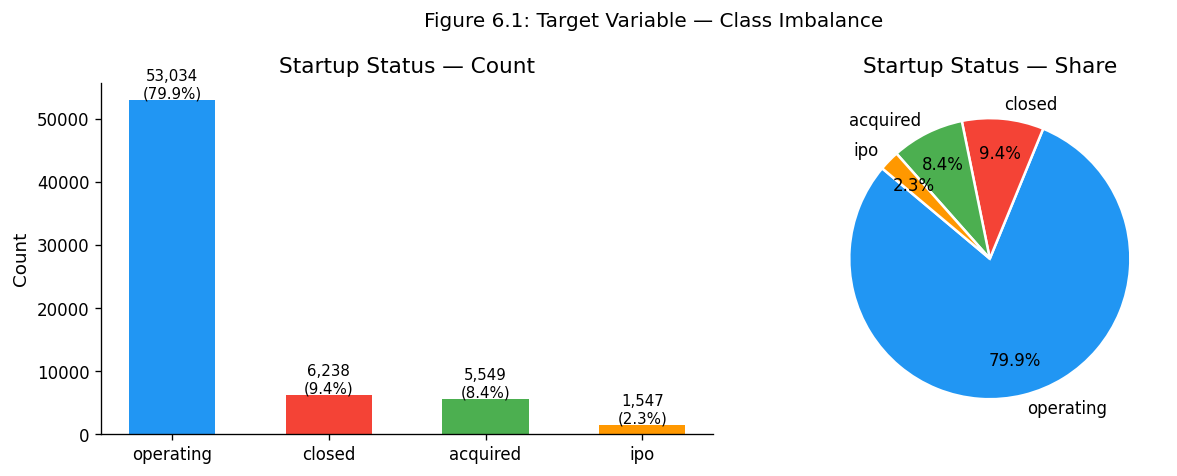

NOTE: 79.9% operating — SMOTE will be required before modelling.


In [13]:
# Figure 6.1 — Target class distribution (bar + pie)
status_counts = df['status'].value_counts()
status_pct    = df['status'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = [PALETTE[s] for s in status_counts.index]

axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='none', width=0.55)
axes[0].set_title('Startup Status — Count')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(status_counts.values, status_pct.values)):
    axes[0].text(i, v + 300, f'{v:,}\n({p:.1f}%)', ha='center', fontsize=9)

axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Startup Status — Share')

plt.suptitle('Figure 6.1: Target Variable — Class Imbalance', fontsize=12)
plt.tight_layout()
plt.savefig('fig2_status_distribution.png', bbox_inches='tight')
plt.show()
print('NOTE: 79.9% operating — SMOTE will be required before modelling.')

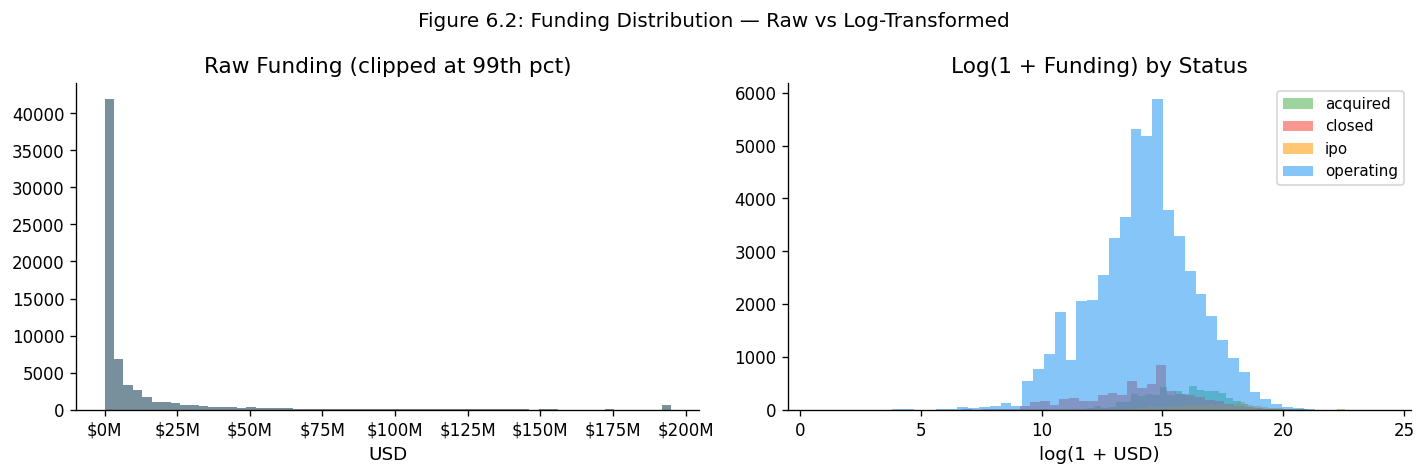

In [14]:
# Figure 6.2 — Funding distribution: raw vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw funding (clipped at 99th percentile to show the bulk of data)
p99 = df['funding_total_usd'].quantile(0.99)
axes[0].hist(df['funding_total_usd'].clip(upper=p99), bins=60,
             color='#78909C', edgecolor='none')
axes[0].set_title('Raw Funding (clipped at 99th pct)')
axes[0].set_xlabel('USD')
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

# Log-transformed, coloured by status
for status, grp in df.groupby('status'):
    axes[1].hist(grp['log_funding'], bins=50, alpha=0.55,
                 color=PALETTE[status], label=status, edgecolor='none')
axes[1].set_title('Log(1 + Funding) by Status')
axes[1].set_xlabel('log(1 + USD)')
axes[1].legend(fontsize=9)

plt.suptitle('Figure 6.2: Funding Distribution — Raw vs Log-Transformed', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_funding_distribution.png', bbox_inches='tight')
plt.show()

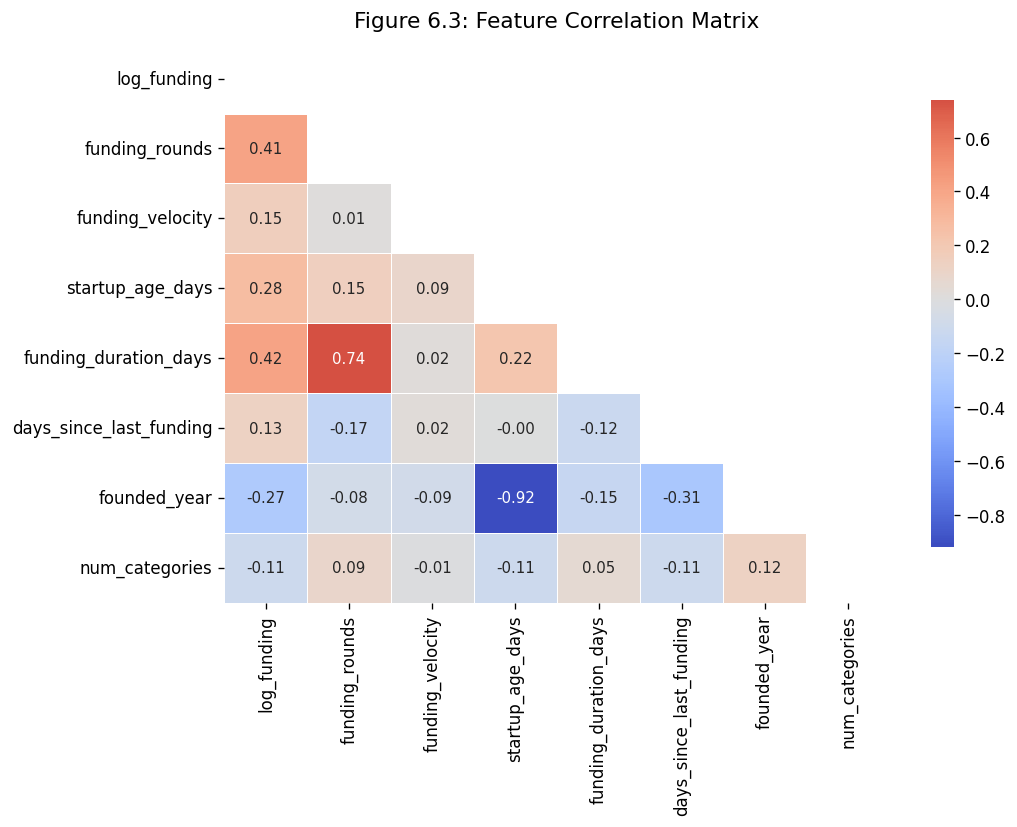

In [15]:
# Figure 6.3 — Correlation heatmap
num_features = [
    'log_funding', 'funding_rounds', 'funding_velocity',
    'startup_age_days', 'funding_duration_days',
    'days_since_last_funding', 'founded_year', 'num_categories'
]
corr = df[num_features].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.4, ax=ax, annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Figure 6.3: Feature Correlation Matrix', pad=10)
plt.tight_layout()
plt.savefig('fig4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

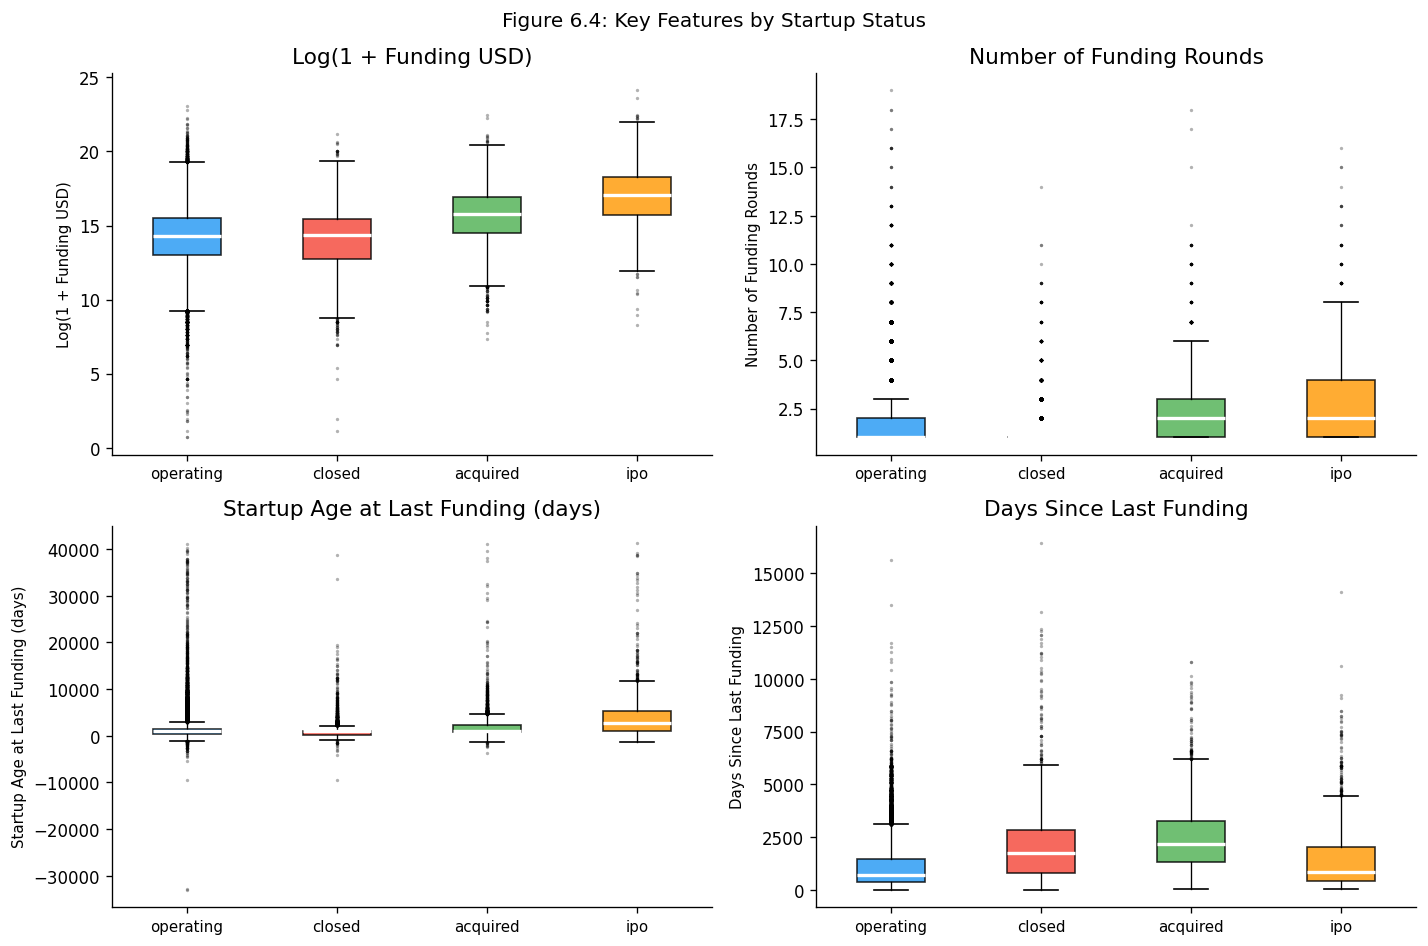

In [16]:
# Figure 6.4 — Key features by status (boxplots)
features_to_plot = [
    ('log_funding',            'Log(1 + Funding USD)'),
    ('funding_rounds',         'Number of Funding Rounds'),
    ('startup_age_days',       'Startup Age at Last Funding (days)'),
    ('days_since_last_funding','Days Since Last Funding'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (feat, label) in zip(axes, features_to_plot):
    data_plot = [
        df.loc[df['status'] == s, feat].dropna()
        for s in ['operating', 'closed', 'acquired', 'ipo']
    ]
    bp = ax.boxplot(
        data_plot, patch_artist=True,
        medianprops={'color': 'white', 'linewidth': 2},
        whiskerprops={'linewidth': 0.8},
        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3}
    )
    for patch, status in zip(bp['boxes'], ['operating', 'closed', 'acquired', 'ipo']):
        patch.set_facecolor(PALETTE[status])
        patch.set_alpha(0.8)
    ax.set_xticklabels(['operating', 'closed', 'acquired', 'ipo'], fontsize=9)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(label)

plt.suptitle('Figure 6.4: Key Features by Startup Status', fontsize=12)
plt.tight_layout()
plt.savefig('fig5_features_by_status.png', bbox_inches='tight')
plt.show()

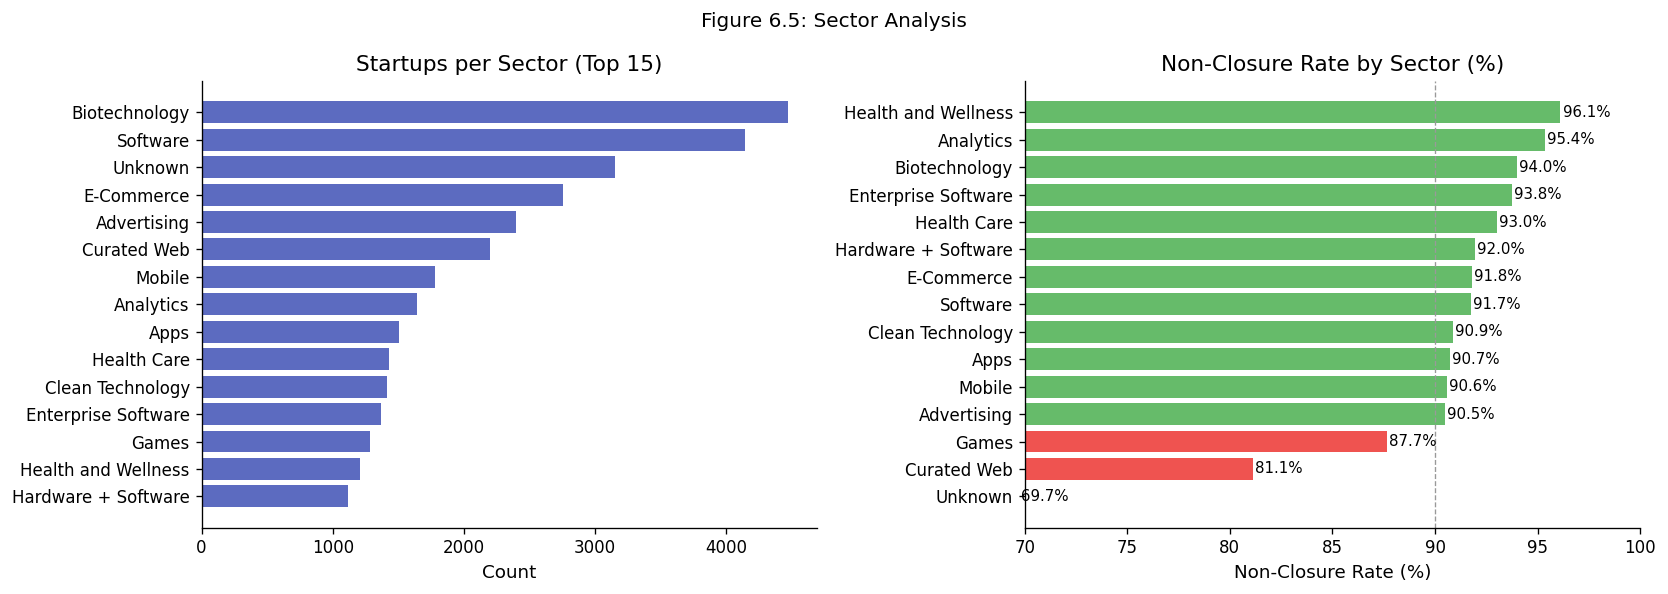

In [17]:
# Figure 6.5 — Top sectors and their non-closure rates
top_cats = df['primary_category'].value_counts().head(15).index
sector_df = df[df['primary_category'].isin(top_cats)]

survival_rate = (
    sector_df.groupby('primary_category')['status']
    .apply(lambda x: (x != 'closed').mean() * 100)
    .sort_values()
)
sector_counts = sector_df['primary_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(sector_counts.index, sector_counts.values, color='#5C6BC0', edgecolor='none')
axes[0].set_title('Startups per Sector (Top 15)')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

colors_s = ['#EF5350' if v < 88 else '#66BB6A' for v in survival_rate.values]
axes[1].barh(survival_rate.index, survival_rate.values, color=colors_s, edgecolor='none')
axes[1].axvline(90, color='#999', linestyle='--', linewidth=0.8)
axes[1].set_xlim(70, 100)
axes[1].set_title('Non-Closure Rate by Sector (%)')
axes[1].set_xlabel('Non-Closure Rate (%)')
for i, v in enumerate(survival_rate.values):
    axes[1].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Figure 6.5: Sector Analysis', fontsize=12)
plt.tight_layout()
plt.savefig('fig6_sector_analysis.png', bbox_inches='tight')
plt.show()

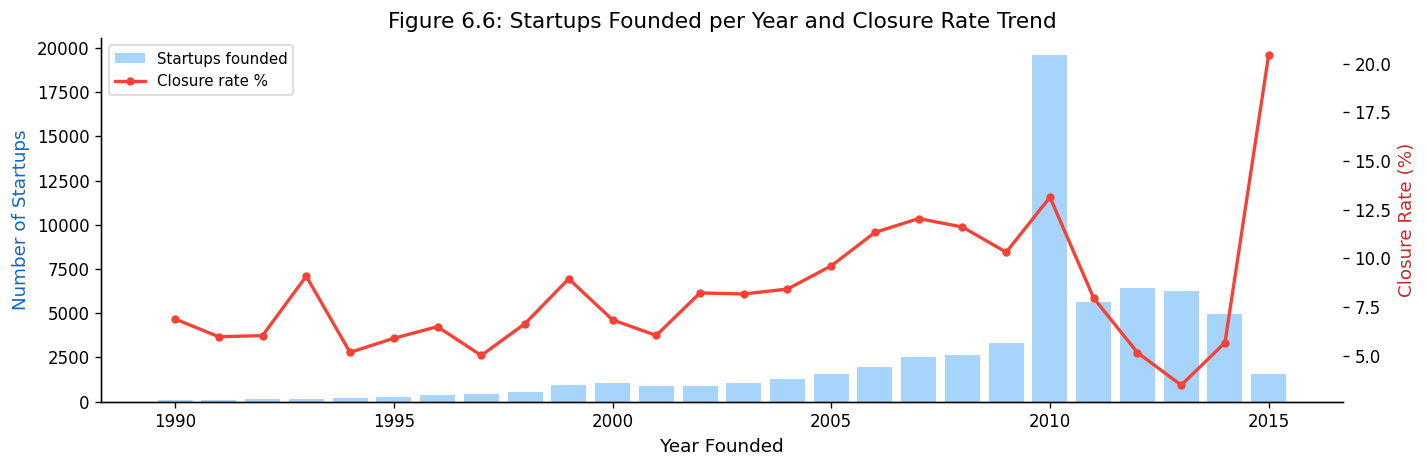

In [18]:
# Figure 6.6 — Startups founded per year + closure rate trend
year_df = df[(df['founded_year'] >= 1990) & (df['founded_year'] <= 2015)]
year_counts  = year_df.groupby('founded_year')['status'].count()
year_closure = year_df.groupby('founded_year')['status'].apply(
    lambda x: (x == 'closed').mean() * 100
)

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(year_counts.index, year_counts.values, color='#90CAF9',
        alpha=0.8, edgecolor='none', label='Startups founded')
ax2.plot(year_closure.index, year_closure.values, color='#F44336',
         linewidth=2, marker='o', markersize=4, label='Closure rate %')

ax1.set_xlabel('Year Founded')
ax1.set_ylabel('Number of Startups', color='#1565C0')
ax2.set_ylabel('Closure Rate (%)', color='#C62828')
ax1.set_title('Figure 6.6: Startups Founded per Year and Closure Rate Trend')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
plt.tight_layout()
plt.savefig('fig7_founding_year_trend.png', bbox_inches='tight')
plt.show()

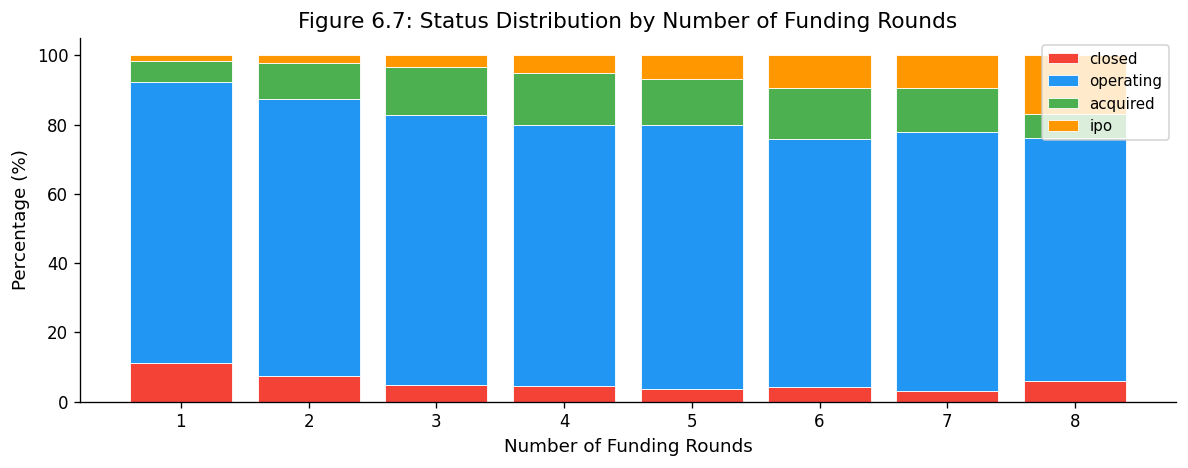

Key insight: more funding rounds = lower closure rate.


In [19]:
# Figure 6.7 — Funding rounds vs status (stacked bar)
rounds_status = (
    df.groupby(['funding_rounds', 'status'])
    .size()
    .unstack(fill_value=0)
    .iloc[:8]   # rounds 1 through 8
)
rounds_pct = rounds_status.div(rounds_status.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(rounds_pct))
for status in ['closed', 'operating', 'acquired', 'ipo']:
    if status in rounds_pct.columns:
        ax.bar(rounds_pct.index, rounds_pct[status], bottom=bottom,
               label=status, color=PALETTE[status],
               edgecolor='white', linewidth=0.5)
        bottom += rounds_pct[status].values

ax.set_xlabel('Number of Funding Rounds')
ax.set_ylabel('Percentage (%)')
ax.set_title('Figure 6.7: Status Distribution by Number of Funding Rounds')
ax.legend(fontsize=9, loc='upper right')
ax.set_xticks(rounds_pct.index)
plt.tight_layout()
plt.savefig('fig8_rounds_vs_status.png', bbox_inches='tight')
plt.show()
print('Key insight: more funding rounds = lower closure rate.')

## **Geographic & Africa Subgroup Analysis**

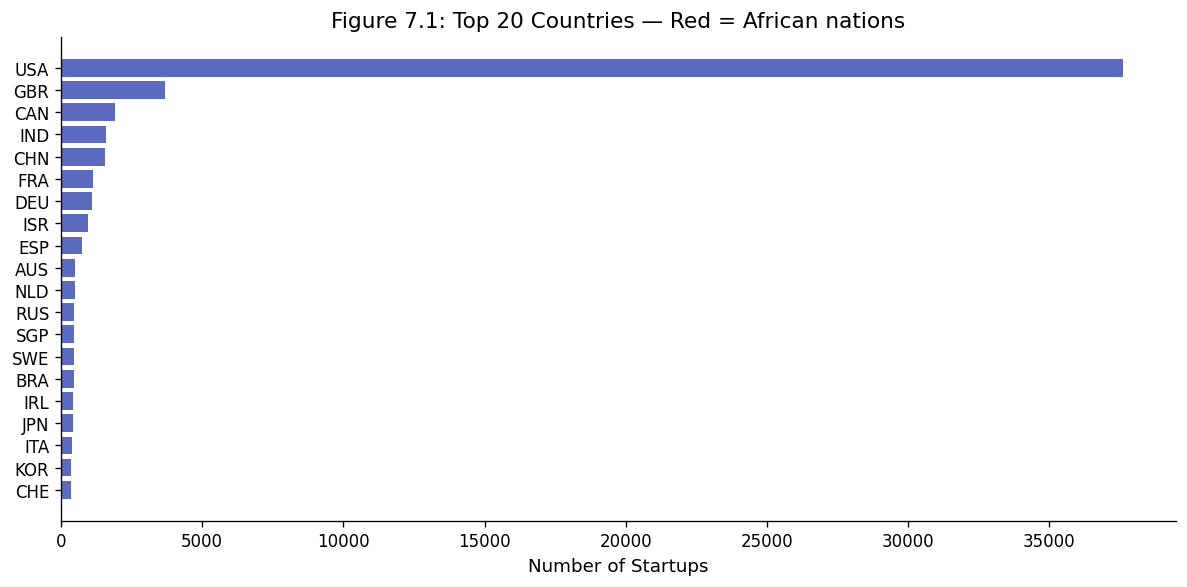

African records : 275 (0.41% of dataset)
Kenyan records  : 39 (0.06% of dataset)


In [20]:
# 7.1 — Top 20 countries by startup count (Africa highlighted in red)
top_countries = df[df['country_code'] != 'UNK']['country_code'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#EF5350' if c in AFRICA_CODES else '#5C6BC0'
              for c in top_countries.index]
ax.barh(top_countries.index[::-1], top_countries.values[::-1],
        color=bar_colors[::-1], edgecolor='none')
ax.set_xlabel('Number of Startups')
ax.set_title('Figure 7.1: Top 20 Countries — Red = African nations')
plt.tight_layout()
plt.savefig('fig9_country_distribution.png', bbox_inches='tight')
plt.show()

africa_df = df[df['is_africa'] == 1]
kenya_df  = df[df['is_kenya']  == 1]
print(f'African records : {len(africa_df)} ({len(africa_df)/len(df)*100:.2f}% of dataset)')
print(f'Kenyan records  : {len(kenya_df)} ({len(kenya_df)/len(df)*100:.2f}% of dataset)')

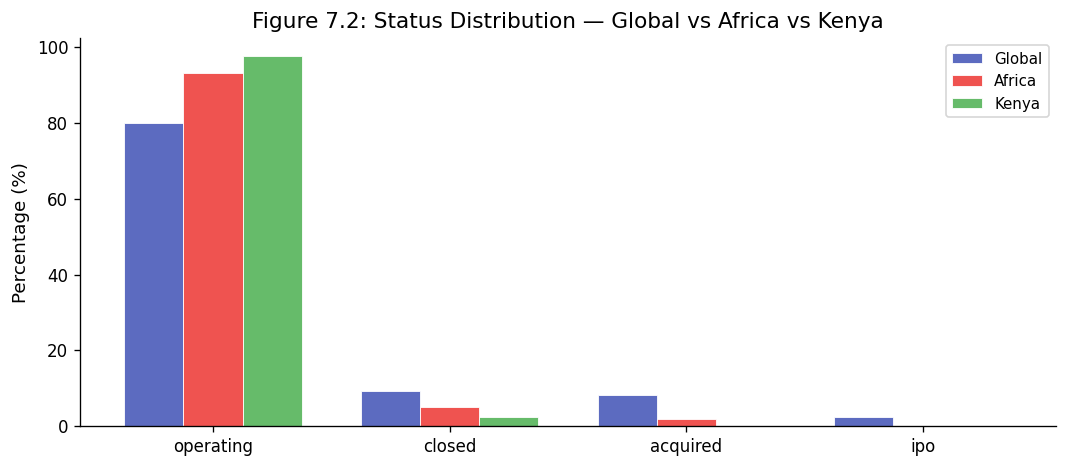

           Global  Africa  Kenya
status                          
operating   79.90   93.10  97.40
closed       9.40    5.10   2.60
acquired     8.40    1.80   0.00
ipo          2.30    0.00   0.00


In [21]:
# 7.2 — Status distribution: Global vs Africa vs Kenya
def status_dist(subset, label):
    return subset['status'].value_counts(normalize=True).rename(label) * 100

compare = pd.concat([
    status_dist(df, 'Global'),
    status_dist(africa_df, 'Africa'),
    status_dist(kenya_df, 'Kenya'),
], axis=1).fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))
x     = np.arange(len(compare))
width = 0.25
group_colors = ['#5C6BC0', '#EF5350', '#66BB6A']
for i, (col, color) in enumerate(zip(compare.columns, group_colors)):
    ax.bar(x + i * width, compare[col], width, label=col,
           color=color, edgecolor='white', linewidth=0.5)
ax.set_xticks(x + width)
ax.set_xticklabels(compare.index)
ax.set_ylabel('Percentage (%)')
ax.set_title('Figure 7.2: Status Distribution — Global vs Africa vs Kenya')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig10_geo_status_comparison.png', bbox_inches='tight')
plt.show()
print(compare.round(1).to_string())

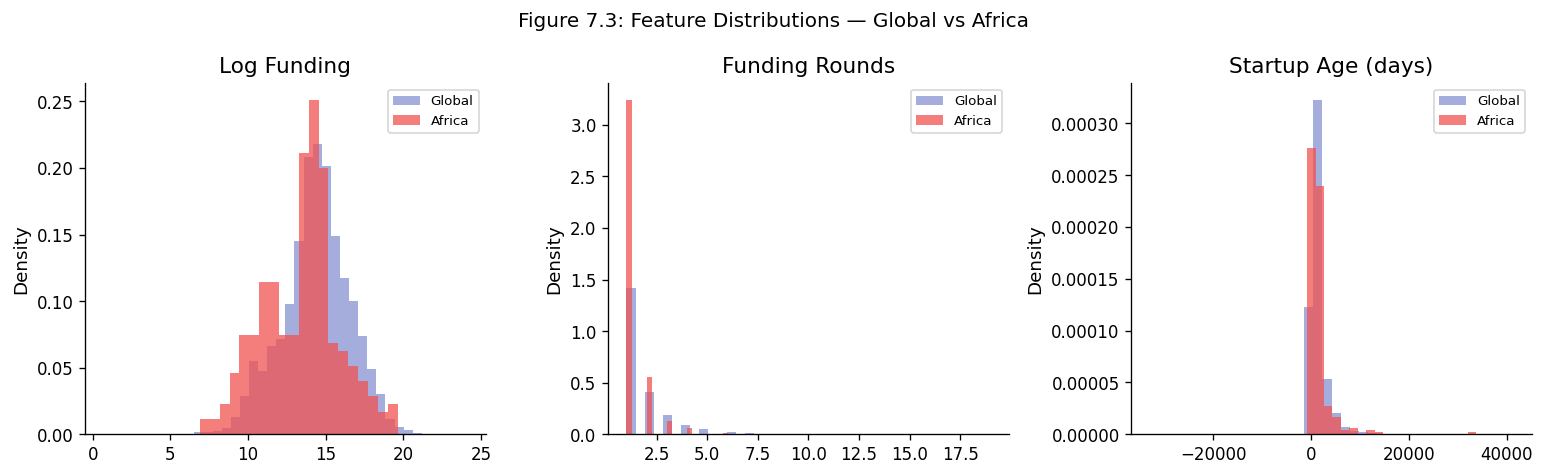

In [22]:
# 7.3 — Feature distribution comparison: Global vs Africa
compare_features = ['log_funding', 'funding_rounds', 'startup_age_days']
compare_labels   = ['Log Funding', 'Funding Rounds', 'Startup Age (days)']

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, feat, label in zip(axes, compare_features, compare_labels):
    ax.hist(df[feat].dropna(), bins=40, alpha=0.55, color='#5C6BC0',
            density=True, label='Global', edgecolor='none')
    ax.hist(africa_df[feat].dropna(), bins=20, alpha=0.75, color='#EF5350',
            density=True, label='Africa', edgecolor='none')
    ax.set_title(label)
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Figure 7.3: Feature Distributions — Global vs Africa', fontsize=12)
plt.tight_layout()
plt.savefig('fig11_africa_feature_comparison.png', bbox_inches='tight')
plt.show()

In [23]:
# 7.4 — Summary statistics table: Global vs Africa vs Kenya
summary_cols = ['log_funding', 'funding_rounds', 'startup_age_days', 'num_categories']
summary = pd.concat([
    df[summary_cols].mean().rename('Global mean'),
    africa_df[summary_cols].mean().rename('Africa mean'),
    kenya_df[summary_cols].mean().rename('Kenya mean'),
], axis=1).round(2)
print('Feature means — Global vs Africa vs Kenya:')
print(summary)
print('\nAfrican startup counts by country:')
print(africa_df['country_code'].value_counts().to_string())

Feature means — Global vs Africa vs Kenya:
                  Global mean  Africa mean  Kenya mean
log_funding             14.37        13.44       13.63
funding_rounds           1.73         1.27        1.38
startup_age_days      1503.65      1330.99     1635.31
num_categories           2.30         2.23        1.72

African startup counts by country:
country_code
ZAF    92
NGA    57
KEN    39
EGY    36
UGA    15
GHA    14
BWA     4
TUN     3
ZWE     3
RWA     3
ZMB     2
MAR     2
MOZ     2
CIV     2
SEN     1


## **Final Validation & Export**

In [24]:
# 8.1 — Define the feature set to carry into Phase 2
MODEL_FEATURES = [
    'log_funding',             # funding size (log-transformed)
    'funding_rounds',          # depth of investor commitment
    'funding_velocity',        # average raise per round
    'startup_age_days',        # maturity at last funding
    'funding_duration_days',   # sustained funding activity
    'days_since_last_funding', # recency signal
    'founded_year',            # economic era
    'num_categories',          # sector diversification
    'is_africa',               # geographic subgroup flag
]

# 8.2 — Encode target variable
# 4-class: operating=0, closed=1, acquired=2, ipo=3
STATUS_MAP = {'operating': 0, 'closed': 1, 'acquired': 2, 'ipo': 3}
df['status_encoded'] = df['status'].map(STATUS_MAP)

# Binary: 0 = still alive (operating/acquired/ipo), 1 = closed
df['is_closed'] = (df['status'] == 'closed').astype(int)

print('4-class target distribution:')
print(df['status_encoded'].value_counts())
print('\nBinary target (is_closed):')
print(df['is_closed'].value_counts())

4-class target distribution:
status_encoded
0    53034
1     6238
2     5549
3     1547
Name: count, dtype: int64

Binary target (is_closed):
is_closed
0    60130
1     6238
Name: count, dtype: int64


In [25]:
# 8.3 — Validate: no nulls in model-ready columns
null_check = df[MODEL_FEATURES + ['status_encoded', 'is_closed']].isnull().sum()
assert null_check.sum() == 0, f'Nulls remain:\n{null_check[null_check > 0]}'
print('Validation passed — 0 null values in model feature set.')
print(f'\nFinal dataset shape: {df.shape}')
print(f'Model features ready: {len(MODEL_FEATURES)}')

Validation passed — 0 null values in model feature set.

Final dataset shape: (66368, 24)
Model features ready: 9


In [26]:
# 8.4 — Descriptive statistics for model features
df[MODEL_FEATURES].describe().round(2)

,log_funding,funding_rounds,funding_velocity,startup_age_days,funding_duration_days,days_since_last_funding,founded_year,num_categories,is_africa
count,66368.00,66368.00,66368.00,66368.00,66368.00,66368.00,66368.00,66368.00,66368.00
mean,14.37,1.73,7999506.92,1503.65,342.08,1284.14,2008.51,2.30,0.00
std,2.18,1.36,99548823.24,2342.32,710.24,1233.01,6.96,1.91,0.06
min,0.69,1.00,1.00,-33055.00,0.00,0.00,1901.00,0.00,0.00
25%,13.12,1.00,377500.00,470.00,0.00,410.00,2008.00,1.00,0.00
50%,14.51,1.00,1475000.00,1012.00,0.00,852.00,2010.00,2.00,0.00
75%,15.78,2.00,4546520.50,1561.00,415.00,1795.00,2012.00,3.00,0.00
max,24.13,19.00,17600000000.00,41329.00,36994.00,16436.00,2105.00,44.00,1.00


In [27]:
# 8.5 — Save both outputs to Google Drive project folder

SAVE_DIR = '/content/drive/MyDrive/Colab Notebooks/Final_Year_Project/'

# Full cleaned dataset (use for reporting and reference)
df.to_csv(SAVE_DIR + 'startup_cleaned_phase1.csv', index=False)

# Lean model-ready file (use in Phase 2)
MODEL_COLS = (MODEL_FEATURES
              + ['status', 'status_encoded', 'is_closed',
                 'name', 'country_code', 'primary_category'])
df[MODEL_COLS].to_csv(SAVE_DIR + 'startup_model_ready.csv', index=False)

print('Saved: startup_cleaned_phase1.csv')
print('Saved: startup_model_ready.csv')
print(f'Location: {SAVE_DIR}')

Saved: startup_cleaned_phase1.csv
Saved: startup_model_ready.csv
Location: /content/drive/MyDrive/Colab Notebooks/Final_Year_Project/
